# Relationship Extraction and Data Storage - `spaCy` and `memgraph`

Feedback/questions: pushpak.karnick@digipen.edu

### Module Objectives

- Read cached named-entity labels from the `spaCy` pipeline
- Extract relationships between entities from the raw text
- Use `memgraph` to store the extracted relationships
- Visualize the graph database stored

## Reading the cached data from disk

In the first module of this lecture, we performed the following actions:
- Identified `characters` from the file _Much Ado About Nothing_ by William Shakespeare
- Fine-tuned `spaCy`'s language model to identify and label real-world entities from our character list
- We also created two new labels - `OCC` for occupation/role, and `REL` for relationship between the characters
- Cached this information to disk in JSON format

Before we proceed, the first thing we do is read this cached data from the disk -

### JSON format for encoding the `spaCy` doc object

An examination of the JSON file `doc.json` shows that it contains the following information:
- The text of the document
- The entities identified in the document
- The entity labels (e.g. 'PERSON', 'OCC', 'REL')
- The character offsets of the entities in the document

```JSON
 "ents": [
        {
            "start": 0,
            "end": 9,
            "label": "PERSON"
        },...
  ]
```

We can load the JSON data into a `spacy` document object by implementing the following steps:
- Load the JSON file into a Python dictionary
- Create a `Doc` object from the raw text (using `['text']` as the key)
- Iterate over the entities in the JSON data and create `Span` objects for each entity
- Return the `Doc` object

In [2]:
import json
import spacy
from spacy.tokens import Doc

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

def loadDocFromJSON(filePath):
    """
    Parses a JSON file to create and restore a `Doc` object with its associated
    entities. The JSON file is expected to contain text and entity metadata
    previously serialized. This function utilizes the NLP model to generate
    a new `Doc` object and restores its entities using the cached data.

    :param filePath: The path to the input JSON file containing the serialized
        document and entity information.
    :type filePath: str
    :return: A `Doc` object with the restored text and entities.
    :rtype: Doc
    """
    # 1. Load the JSON data into a Python object
    with open(filePath, 'r') as inputFile:
        data = json.load(inputFile)

    # 2. Create a Doc object from the cached data - using the ['text'] key
    doc = nlp(data['text'])

    # 3. Restore entities from the cached data
    # For each entity in the JSON data, create a tuple (start, end, label)
    ents = [
        (ent["start"], ent["end"], ent["label"])
        for ent in data.get("ents", [])
    ]

    # For each tuple representing the entity, use `doc.char_span` to create a Span
    doc.ents = [doc.char_span(start, end, label=label) for start, end, label in ents]

    print(doc)
    print("\nEntities:")
    for ent in doc.ents:
        print(f"{ent.text} - {ent.label_}")

    return doc

In [3]:
# Load the JSON file into a spaCy doc object
doc = loadDocFromJSON('doc2.json')

DON PEDRO is Prince of Arragon. DON JOHN is his bastard Brother. CLAUDIO is a young Lord of Florence. BENEDICK is a young Lord of Padua. LEONATO is Governor of Messina. ANTONIO is his Brother. BALTHASAR is Servant to Don Pedro. BORACHIO is follower of Don John. CONRADE is follower of Don John. DOGBERRY is a Constable. VERGES is a Headborough. FRIAR FRANCIS is . UNNAMED is A Sexton. UNNAMED is A Boy. HERO is Daughter to Leonato. BEATRICE is Niece to Leonato. MARGARET is Waiting gentlewoman attending on Hero. URSULA is Waiting gentlewoman attending on Hero. UNNAMED is Messengers, Watch, Attendants, etc.

Entities:
DON PEDRO - PERSON
Prince - OCC
Arragon - GPE
DON JOHN - PERSON
Brother - REL
CLAUDIO - PERSON
Lord - OCC
Florence - GPE
BENEDICK - PERSON
Lord - OCC
Padua - GPE
LEONATO - PERSON
Governor - OCC
Messina - GPE
ANTONIO - PERSON
Brother - REL
BALTHASAR - PERSON
Servant - OCC
Don Pedro - PERSON
BORACHIO - PERSON
follower - OCC
Don John - PERSON
CONRADE - PERSON
follower - OCC
Don Jo

## Extracting Entity Information from the doc

Our next step is to be able to extract all named entities from the sentences and create logical connections between the tokens. However, before we do this, let us observe some of the sentences in our `doc` object.

In [4]:
for sentence in doc.sents:
    print(sentence)

DON PEDRO is Prince of Arragon.
DON JOHN is his bastard Brother.
CLAUDIO is a young Lord of Florence.
BENEDICK is a young Lord of Padua.
LEONATO is Governor of Messina.
ANTONIO is his Brother.
BALTHASAR is Servant to Don Pedro.
BORACHIO is follower of Don John.
CONRADE is follower of Don John.
DOGBERRY is a Constable.
VERGES is a Headborough.
FRIAR FRANCIS is .
UNNAMED is A Sexton.
UNNAMED is A Boy.
HERO is Daughter to Leonato.
BEATRICE is Niece to Leonato.
MARGARET is Waiting gentlewoman attending on Hero.
URSULA is Waiting gentlewoman attending on Hero.
UNNAMED is Messengers, Watch, Attendants, etc.


We observe that in the first sentence, the subject "DON PEDRO" is used as a Noun.
However, in the second sentence, his presence is implied by the pronoun "his." (Similarly with LEONATO and ANTONIO.)

We should account for such dependencies. We can process them in two ways:
- We can check for the appropriate NOUN or subject/object entity at runtime and create the relationship, or
- Similar to our approach in the previous module (A is B), we can _insert_ this information into the text in a way that can be consumed by a NLP pipeline.
- A common approach to achieve this is to replace the pronoun token with the actual object that it refers to. E.g. we can replace 'his' with 'DON PEDRO' in the second sentence.

```JSON
Original sentences:
    DON PEDRO is Prince of Arragon.
    DON JOHN is his bastard Brother.

After replacement:
    DON PEDRO is Prince of Arragon.
    DON JOHN is DON PEDRO's bastard Brother.
```

The latter approach is more popularly used in practice as it is very scalable and only requires the input text for context. This approach is formally known as **Coreference Resolution**, and is an open research problem for English and many other commonly-used languages.

In [5]:
def resolvePronouns(sentences):
    """
    Checks for pronouns in each sentence and resolves them using the previous
    sentence's named entities (PERSON type) via spaCy POS and NER tagging.

    :param sentences: List of spaCy Span objects (sentences from a doc).
    :return: List of strings with pronouns replaced by resolved entity names.
    """
    # Possessive pronoun -> gender hint mapping (basic heuristic)
    POSSESSIVE_PRONOUNS = {'his', 'her', 'their', 'its'}
    SUBJECT_PRONOUNS = {'he', 'she', 'they', 'it'}
    ALL_PRONOUNS = POSSESSIVE_PRONOUNS | SUBJECT_PRONOUNS

    resolved_sentences = []

    # for each sentence in the list passed as argument
    for i, sentence in enumerate(sentences):
        sentenceText = sentence.text

        # Find the specified pronouns in the current sentence
        pronounsFound = [
            token for token in sentence
            if token.pos_ =='PRON' and token.lower_ in ALL_PRONOUNS
        ]

        if pronounsFound and i > 0:
            # A 'look-back' window (or context) of one sentence
            prevSentence = sentences[i - 1]

            # Extract PERSON entities from the previous sentence
            prevPersonToken = [
                ent for ent in prevSentence.ents
                if ent.label_ == "PERSON"
            ]

            if prevPersonToken:
                # Use the last PERSON entity as the antecedent (most recent subject)
                antecedent = prevPersonToken[-1].text

                # Replace the pronoun with the "<person>'s" in the sentence
                for pronounToken in pronounsFound:
                    sentenceText = sentenceText.replace(
                        pronounToken.text, antecedent +"'s", 1
                    )

                print(f"[Resolved] '{sentence.text.strip()}'\n"
                      f"        -> '{sentenceText.strip()}'\n"
                      f"           (pronoun '{pronounsFound[0].text}' -> '{antecedent}')\n")

        resolved_sentences.append(sentenceText)

    return resolved_sentences


In [6]:
# Apply pronoun resolution to the loaded doc
sentences = list(doc.sents)
resolved = resolvePronouns(sentences)

doc = nlp(' '.join(resolved))
print("--- Resolved Sentences ---")
for s in resolved:
    print(s.strip())


[Resolved] 'DON JOHN is his bastard Brother.'
        -> 'DON JOHN is DON PEDRO's bastard Brother.'
           (pronoun 'his' -> 'DON PEDRO')

[Resolved] 'ANTONIO is his Brother.'
        -> 'ANTONIO is LEONATO's Brother.'
           (pronoun 'his' -> 'LEONATO')

--- Resolved Sentences ---
DON PEDRO is Prince of Arragon.
DON JOHN is DON PEDRO's bastard Brother.
CLAUDIO is a young Lord of Florence.
BENEDICK is a young Lord of Padua.
LEONATO is Governor of Messina.
ANTONIO is LEONATO's Brother.
BALTHASAR is Servant to Don Pedro.
BORACHIO is follower of Don John.
CONRADE is follower of Don John.
DOGBERRY is a Constable.
VERGES is a Headborough.
FRIAR FRANCIS is .
UNNAMED is A Sexton.
UNNAMED is A Boy.
HERO is Daughter to Leonato.
BEATRICE is Niece to Leonato.
MARGARET is Waiting gentlewoman attending on Hero.
URSULA is Waiting gentlewoman attending on Hero.
UNNAMED is Messengers, Watch, Attendants, etc.


### Coreference Resolution

Our approach here is very bespoke - it is tailored to the input data that we are parsing, and as such it would change drastically depending on the nature of the text. To be more specific:

The nature of our input data -

_A is B_, and

_C is \<some relationship with\> A_

allows our resolver to look back exactly **one** sentence to search for _A_, the **only** _antecedent_.

In code:
```JSON
    prevSentence = sentences[i - 1]
    ...
    antecedent = prevPersonToken[-1].text
```

In [1]:
from KG_Common import displayEntities
displayEntities(doc)

NameError: name 'doc' is not defined


Let us think about the following sentences:

```JSON
Alice and Bob went out to get some ice-cream. He got chocolate. She opted for raspberry swirl.
```

The preceding sentences have a set of antecedents and pronoun matching pairs: `{('Alice', 'she'), ('Bob', 'he')}`. However, the **context** to look back has expand**ed from one to two sentences**. In practice, models employ a context of 1000-2500 characters to resolve such multi-sentence references. This is still not a very difficult scenario to parse since the two antecedents can be disambiguated on the basis of their gender pointers. It would be more difficult to do so for these sentences:

```JSON
Sarah was forced to go up to Gemma's home. She wanted to collect the books that she borrowed last week.
```

Now, the antecedent pairs are ambiguous: `{('Sarah', 'she'), ('Gemma', 'she')}`, and while a human can intuitively apply English grammar rules to resolve which `she` goes with which `Noun`, coding this into an algorithm is more complex than the simple coreference resolver we have implemented above. This phenomenon is also known as **Antecedent Clustering**. Yet another configuration which is very commonly found in real-world text is **Split Antecedents**, where the antecedents for two matching pairs overlap in their `span` within the sentence.

```JSON
Alice and Bob went out to get some ice-cream. They both got chocolate and he paid for the treats since he had lost their bet.
```

In the above sentences the antecedents pairs are `{( 'Alice and Bob', 'They' ), ('Bob', 'he'), ('Alice and Bob', 'their')}` and the resolver would have to correctly assign the antecedent pair without any overlap in their `span` to account for ambiguity.

In [ ]:
from KG_Common import displayEntities

resolvedText = ' '.join(resolved)
doc = nlp(resolvedText)
displayEntities(doc)

Unfortunately, the word replacement has messed up our entities from the original text, as the `entities` contain explicit links to the token `span`.

In [ ]:
from KG_Common import merge_tokens_to_ner

doc = merge_tokens_to_ner(doc, ["DON", "PEDRO"])
doc = merge_tokens_to_ner(doc, ["DON", "JOHN"])

displayEntities(doc)

In [ ]:
# Fine-tuning using existing tag information

# 0-10
doc = merge_tokens_to_ner(doc, ["CLAUDIO"])
doc = merge_tokens_to_ner(doc, ["BENEDICK"])
doc = merge_tokens_to_ner(doc, ["Florence"], "GPE")
doc = merge_tokens_to_ner(doc, ["LEONATO"])
doc = merge_tokens_to_ner(doc, ["ANTONIO"])
doc = merge_tokens_to_ner(doc, ["BALTHASAR"])
doc = merge_tokens_to_ner(doc, ["CONRADE"])
doc = merge_tokens_to_ner(doc, ["DOGBERRY"])

# 11-20 (can be batched for readability in a production environment)
names = ["VERGES", "FRANCIS", "HERO", "BEATRICE", "MARGARET", "URSULA"]
for name in names:
    doc = merge_tokens_to_ner(doc, [name], "PERSON")

tokenList = [ "Prince",
              "Lord",
              "FRIAR",
              "Governor",
              "Servant",
              "Constable",
              "Headborough",
              "follower",
              "Messengers",
              "Attendants",
              "Watch"]

for token in tokenList:
    doc = merge_tokens_to_ner(doc, [token], "OCC")

doc = merge_tokens_to_ner(doc, ["Waiting", "gentlewoman"], "OCC")

tokenList = [ "Brother",
              "Daughter",
              "Niece",
            ]

for token in tokenList:
    doc = merge_tokens_to_ner(doc, [token], "REL")

displayEntities(doc)

## Storing relationships in a Graph Database

Our data represents entities corresponding to characters in a play. Along with the name of the character, we have a accompanying description that describes their occupation and relationship with other characters. This information can be stored as a graph with nodes and edges. The nodes would correspond to the entities, or things, and the edges would represent the relationships between the entities. Fortunately, we have fine-tuned the `spaCy` model to correctly identify the entities and their relationships from our file.

The library that we are going to use to represent our graph is known as `Memgraph` (https://memgraph.com/). It is an open source software that also includes command-line tools, and a web interface (`Memgraph Lab` – https://memgraph.com/docs/memgraph-lab) to manage the data. `Memgraph` uses the `Cypher` query language, which is supported by other graph databases like `neo4j`.

Storing our data into a graph database structure will follow the following steps:
- Pre-process our data to identify the entities and their relationships
- Create a graph database
- Create a schema for our graph
- Insert our data into the graph
- Query the graph for the desired information
- Visualize the graph

### Data Pre-processing

From our labeled data, we will divide the named-entities into the following groups:
- tokens marked as 'GPE' or 'PERSON' are nodes in the graph
- tokens marked as 'OCC' and 'REL' are edges that connect the nodes
- (Optional) tokens that have the adjective POS tag (e.g. 'bastard') are attributes related to the nodes ('DON JOHN')

#### Extracting node information

To populate the nodes of our graph, we should employ the following steps:
- Identify tokens, or token spans, associated with the entity labels that we are interested in ('GPE' or 'PERSON')
- Extract and store the following information for each identified entity:
    - Entity name (lowercased text)
    - Entity type
- Create a unique identifier that will be associated with the graph node (to avoid referencing duplicates, or incorrect nodes having the same text)
- Store the `( unique id, text, label )` in a dictionary
- Add this dictionary to a list

In [12]:
def classifyEntities(doc):
    """
    Processes a document to extract specific entity information and organizes it into a list of
    unique entity entries, each containing an ID, name, and type. This function focuses on
    geopolitical entities (GPE) and persons (PERSON) to create structured data for potential usage
    in knowledge graph construction or further entity-based analyses.

    :param doc: The input document to process. It must have already been analyzed for named
        entities (e.g., through NLP pipelines such as spaCy) and contain an `ents` property.
    :type doc: Any

    :return: A list of dictionaries, where each dictionary represents an entity with the
        attributes "id" (unique identifier), "name" (lowercased text of the entity),
        and "type" (entity type, e.g., GPE or PERSON).
    :rtype: List[Dict[str, Union[int, str]]]
    """
    entityList = []
    for j, ent in enumerate(doc.ents):
        # Only include entities labeled as a geopolitical entity (GPE) or person (PERSON)
        # These will serve as nodes in the knowledge graph
        if ent.label_ in ["GPE", "PERSON"]:
            # Avoid duplicates by checking if the entity name already exists in the list
            if ent.text.lower() not in [e["name"] for e in entityList]:
                # Assign a unique ID based on current list length
                entityID = len(entityList)
                entityList.append({"id": entityID, "name": ent.text.lower(), "type": ent.label_})
    return entityList

In [13]:
# Extract and display all unique GPE/PERSON entities from the processed doc
entList = classifyEntities(doc)
print(entList)

[{'id': 0, 'name': 'don john', 'type': 'PERSON'}, {'id': 1, 'name': 'padua', 'type': 'GPE'}, {'id': 2, 'name': 'messina', 'type': 'GPE'}, {'id': 3, 'name': 'servant', 'type': 'PERSON'}, {'id': 4, 'name': 'don pedro', 'type': 'PERSON'}, {'id': 5, 'name': 'borachio', 'type': 'PERSON'}, {'id': 6, 'name': 'headborough', 'type': 'GPE'}, {'id': 7, 'name': 'sexton', 'type': 'GPE'}, {'id': 8, 'name': 'daughter to leonato', 'type': 'PERSON'}, {'id': 9, 'name': 'niece', 'type': 'PERSON'}, {'id': 10, 'name': 'leonato', 'type': 'PERSON'}]


The next step involves forming a directed relationship between the entities identified in the text. However, knowing the NER label does not help us understand (and encode!) the correct relationships.

E.g. Borachio should be identified as the follower of Don Pedro, and not the other way around.

These _dependencies_ are already encoded in the `dep_` member for each entity. Broadly speaking, the **subject** of the sentence is the entity that acts as the **source** and the **object** of the sentence is the entity that acts as the **target** of the relationship. We have previously seen these concepts labeled using `nsubj` and `dobj/pobj` respectively for simple sentences. The presence of compound noun phrases/chunks, and more complex sentences may result in a larger set of labels being considered. Let us first check the `dep_` labels of our entities to see which ones we shall utilize.

In [14]:
# sandbox - let us check the dependency labels for the entities in the text
for ent in doc.ents:
    print(ent.text, ent.label_, ent.root.dep_, ent.root.head.text)

DON ORG compound PEDRO
DON JOHN PERSON nsubj is
CLAUDIO ORG nsubj is
BENEDICK ORG nsubj is
Padua GPE pobj of
LEONATO ORG nsubj is
Messina GPE pobj of
Servant PERSON attr is
Don Pedro PERSON pobj to
BORACHIO PERSON nsubj is
Don John PERSON pobj of
Don John PERSON pobj of
Constable ORG attr is
VERGES ORG nsubj is
Headborough GPE attr is
Sexton GPE ROOT Sexton
Daughter to Leonato PERSON attr is
Niece PERSON attr is
Leonato PERSON pobj to
Watch, Attendants ORG attr is


In [15]:
# sandbox - let us visualize the first two sentences
from spacy import displacy

# Get the first two sentences
sentenceList = list(doc.sents)[:2]

# Combine them into a single span for visualization
doc1 = nlp(sentenceList[0].text)
doc2 = nlp(sentenceList[1].text)
# Display the dependency graph
displacy.render(doc1, style='dep', jupyter=True)
displacy.render(doc2, style='dep', jupyter=True)


### Observations

- "DON PEDRO" is identified as the part of a _compound noun phrase_ in both sentences
- "DON PEDRO" is classified as the _nominal subject_ of the first sentence (using `nsubj` label)
- "DON PEDRO" is stored in our language document as a `PERSON` entity

So our (very simple) approach to first identifying good candidate-nodes in the graph is to extract tokens that fulfil the above conditions to extract tokens representing persons who are the subject of some actions.

We can repeat the same exercise to identify places - _what NER label and dependency tag combination can we use_?

In [16]:
def mapEntitiesWithRelationships(doc, entityList):
    """
    Goes through each sentence in the doc, extracts entities, and connects
    GPE or PERSON entities with any OCC or REL entity found in the same sentence.
    The subject entity (nsubj) is the source, the object entity (pobj/dobj) is the target,
    and the OCC/REL entity is the relationship.

    :param doc: spaCy Doc object with labeled entities.
    :param entityList: List of entity dicts with 'id', 'name', 'type' keys.
    :return: List of relationship dicts with 'source', 'target', 'relation', 'relation_type'.
    """
    # Build a fast lookup: entity name (lowercase) -> entity ID
    entityNameToId = {e["name"]: e["id"] for e in entityList}
    relationships = []

    for sentence in doc.sents:
        sent_ents = list(sentence.ents)

        # --- Classify entities by their syntactic dependency role ---

        # Subject entities: GPE or PERSON acting as the nominal subject (nsubj)
        # These will be the source nodes in the knowledge graph
        subjectEntities = [
            ent for ent in sent_ents
            if ent.label_ in ["GPE", "PERSON"] and ent.root.dep_ == "nsubj"
        ]

        # Object entities: GPE or PERSON in object/complement positions
        # These will be the target nodes in the knowledge graph
        objectEntities = [
            ent for ent in sent_ents
            if ent.label_ in ["GPE", "PERSON"] and ent.root.dep_ in ["dobj", "pobj", "attr"]
        ]

        # Edge entities: OCC (occupation/role) or REL (relationship) tokens
        # These define the type of connection (edge) between source and target nodes
        edgeEntities = [
            ent for ent in sent_ents
            if ent.label_ in ["OCC", "REL"]
        ]

        # Skip sentences that lack both a subject entity and a relationship/role token
        if not subjectEntities or not edgeEntities:
            continue

        for subj_ent in subjectEntities:
            source_name = subj_ent.text.lower()

            # Skip if the subject entity is not in the known entity list
            if source_name not in entityNameToId:
                continue

            for edge_ent in edgeEntities:
                # Find the closest valid object entity (target) in the sentence, if any
                # The first object entity that differs from the source and exists in the entity list is used
                target_name = None
                target_id = None
                for obj_ent in objectEntities:
                    candidate = obj_ent.text.lower()
                    if candidate in entityNameToId and candidate != source_name:
                        target_name = candidate
                        target_id = entityNameToId[candidate]
                        break  # Use only the first valid target found

                # Build the relationship record (graph edge)
                rel = {
                    "source_id": entityNameToId[source_name],
                    "source": source_name,
                    "relation": edge_ent.text.lower(),  # The connecting label (e.g. 'prince', 'brother')
                    "relation_type": edge_ent.label_,  # OCC or REL
                    "target": target_name,  # None if no object entity found
                    "target_id": target_id,  # None if no object entity found
                }

                # Avoid adding duplicate relationships
                if rel not in relationships:
                    relationships.append(rel)

    return relationships


In [17]:
# Extract all entity relationships from the processed doc using the known entity list
relationshipList = mapEntitiesWithRelationships(doc, entList)

# Display each extracted relationship (source --[relation]--> target)
for r in relationshipList:
    print(r)


### Writing data into the database using `Cypher` query language

**Graph databases** store data as a network of **nodes** (entities) and **edges** (relationships), making them ideal for representing highly connected data such as social networks, knowledge graphs, or — as in our case — character relationships in a play. Unlike relational databases that use tables and joins, graph databases allow for intuitive and efficient traversal of complex relationship structures.

[**Memgraph**](https://memgraph.com/) is an open-source, in-memory graph database built for high performance. It exposes a web interface called **Memgraph Lab** for visual exploration and management of graph data. Memgraph uses [**Cypher**](https://opencypher.org/), a declarative graph query language originally developed for `Neo4j`. Cypher uses an ASCII-art style syntax to describe graph patterns — for example,

`(a)-[:KNOWS]->(b)`

represents a directed relationship from node `a` to node `b` — making queries highly readable and expressive.

In the cells below, we will use the `gqlalchemy` Python library to connect to Memgraph and execute Cypher queries to populate our graph with the entities and relationships extracted above.

#### Initialize the connection

The `gqlalchemy` library is a wrapper around the `gql` library, that allows the execution of Graph Query-Language statements within `python`. We will utilize the `Memgraph` package within `gqlalchemy` to connect and manage data on the `Memgraph` database.

The database is currently located on our local server, so IP='127.0.0.1'. The default connection port for `Memgraph` is 7687.

In [19]:
from gqlalchemy import Memgraph

# Connect to Memgraph (default host/port)
mg = Memgraph(host='127.0.0.1', port=7687)

# Clear existing data
mg.execute("MATCH (n) DETACH DELETE n")

#### Create the nodes of the graph

Nodes are created in Cypher using the `CREATE` command for each node being created.

### Creating the nodes

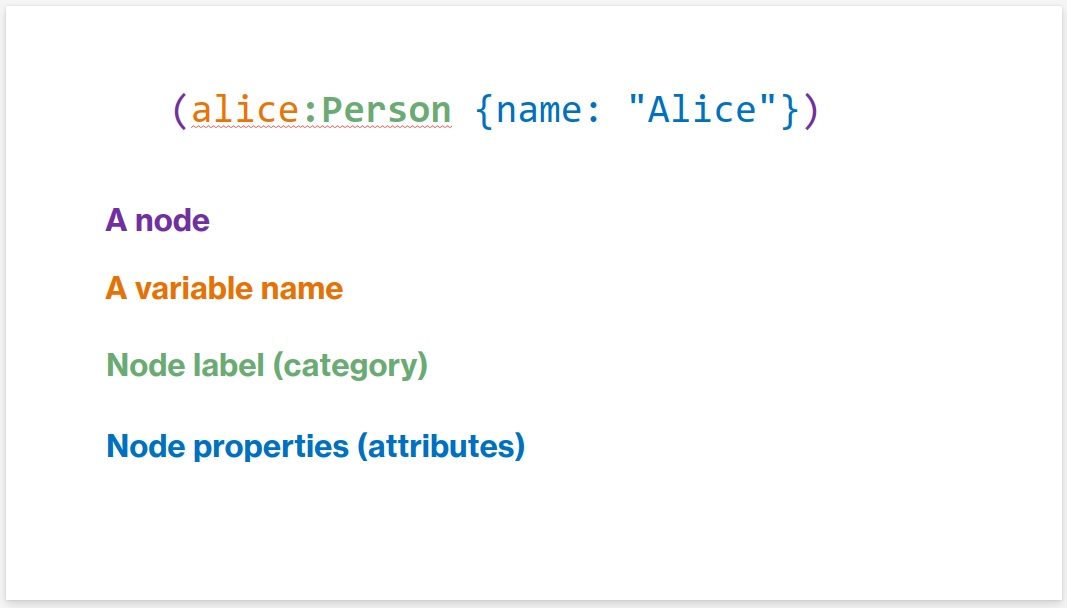


We can collect the output from the previous cell and compare it to the Cyper format for node-specification:
```JSON
{'id': 0, 'name': 'don pedro', 'type': 'PERSON'}
{'id': 1, 'name': 'arragon', 'type': 'GPE'}
```

The Cypher command to create a node for Don Pedro would look like this -
```cypher
CREATE (n:PERSON {id:0, name: 'don pedro'})
```
while the one for Arragon would be

```cypher
CREATE (n:GPE {id:1, name: 'arragon'})
```

Run the above commands in the Cypher Editor in Mamgraph Lab to create the nodes.

In [21]:
# Create nodes from entList
for entity in entList:
    label = entity["type"]   # e.g. PERSON or GPE
    mg.execute(
        f"CREATE (n:{label} {{id: $id, name: $name, type: $type}})",
        {
            "id": entity["id"],
            "name": entity["name"],
            "type": entity["type"],
        }
    )

print(f"Created {len(entList)} nodes.")

Created 11 nodes.


### Creating the relationships

Let us use a similar process to create the relationship edges in the graph -

In [26]:
for rel in relationshipList[:2]:
    print(rel)

We have the following information from the above data, for each relationship (edge):
- `source_id` is the index of the source node in the entity list
- `target_id` is the index of the target node in the entity list
- `relation` is the label of the relationship (e.g. 'prince')

We first need to find the source and target nodes in the graph,
```cypher
MATCH (src {id: source_id} ), (tgt {id: target_id})
```
E.g.
```cypher
MATCH (src {id: 0} ), (tgt {id: 1})
```
returns node point to Don Pedro in `src` and Arragon in `tgt`.
Once we have the source and target nodes, we can create the relationship edge between them

```cypher
CREATE (src)-[r:PRINCE {{relation_type: 'OCC'}}]->(tgt)
```

More generally,
```cypher
CREATE (src)-[r:{rel_type} {{relation_type: relation_type}}]->(tgt)
```
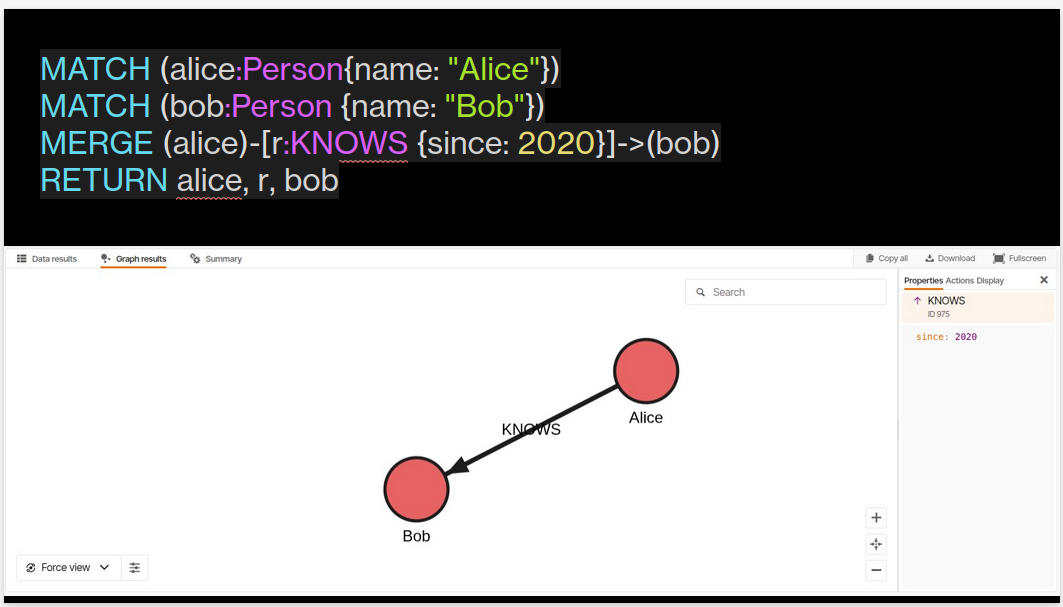

In [23]:

# Create edges from relationshipList
edge_count = 0
for rel in relationshipList:
    if rel['target_id'] is None:
        # No target: add relation as a property on the source node
        mg.execute(
            "MATCH (src {id: $src_id}) SET src.role = $relation",
            {"src_id": rel['source_id'], "relation": rel['relation']}
        )
    else:
        # Create a directed edge between source and target
        rel_type = rel['relation'].upper().replace(' ', '_')
        mg.execute(
            f"""
            MATCH ???
            CREATE ???
            """,
            {
                "src_id": rel['source_id'],
                "tgt_id": rel['target_id'],
                "relation_type": rel['relation_type']
            }
        )
        edge_count += 1

print(f"Created {edge_count} edges.")
print("Memgraph population complete.")


Created 0 edges.
Memgraph population complete.


## Visualizing the data

We will use the `Memgraph Lab` application to visualize the database that we have populated. The `Cypher` query to display the entire graph is as follows:

`MATCH p=()--()`

`RETURN p;`



In [24]:
import gc

gc.collect()

1871